In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
#Load the Dataset
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
#Select Required Features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [9]:
#Choose Number of Clusters
k = 3

In [10]:
#Select Initial Medoids
medoids = X[[0,50,100]]

In [11]:
#Distance Function
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

In [12]:
#Create Empty Clusters
clusters = [[] for i in range(k)]

In [13]:
#Assign Customers to Nearest Medoid
for point in X:

    d1 = distance(point, medoids[0])
    d2 = distance(point, medoids[1])
    d3 = distance(point, medoids[2])

    d = [d1,d2,d3]

    cluster_index = np.argmin(d)

    clusters[cluster_index].append(point)

In [14]:
#Convert Clusters to Arrays
clusters = [np.array(cluster) for cluster in clusters]

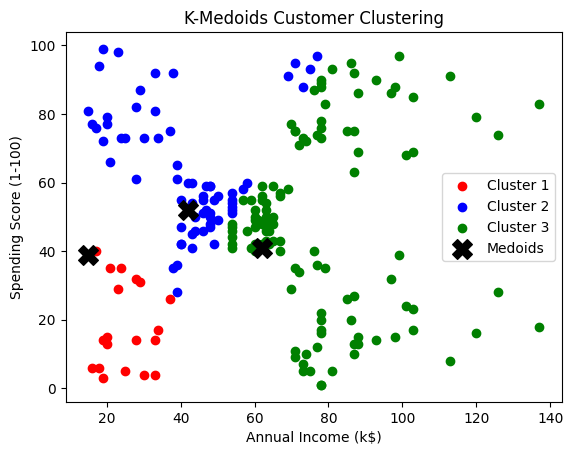

In [15]:
#Plot the Graph
colors = ['red','blue','green']

for i in range(k):
    plt.scatter(clusters[i][:,0], clusters[i][:,1], color=colors[i], label=f'Cluster {i+1}')

plt.scatter(medoids[:,0], medoids[:,1], color='black', marker='X', s=200, label='Medoids')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Medoids Customer Clustering")

plt.legend()
plt.show()